# 2D Poisson Solver with Devito + PETSc

Solves the Poisson equation on the unit square $[0,1]^2$:

$$\nabla^2 \phi = f(x,y)$$

with zero Dirichlet boundary conditions and the manufactured RHS

$$f(x,y) = 2x(y-1)(y - 2x + xy + 2)\,e^{x-y}$$

whose exact solution is $\phi(x,y) = e^{x-y} x(1-x) y(1-y)$.

A convergence study verifies second-order accuracy.

## Environment setup

Set PETSc paths **before** importing Devito so the PETSc backend is detected correctly.

In [1]:
import os

os.environ['PETSC_DIR'] = '/home/zl5621/petsc'
os.environ['PETSC_ARCH'] = 'zoe-petsc-section'
os.environ['CC'] = 'mpicc'

## Imports and Devito configuration

In [2]:
import numpy as np

from devito import (Grid, Function, Eq, Operator, switchconfig,
                    configuration, SubDomain)

from devito.petsc import petscsolve, EssentialBC
from devito.petsc.initialize import PetscInitialize

configuration['compiler'] = 'custom'

PetscInitialize()

Operator `kernel_init` ran in 0.06 s


## Boundary subdomains

Four thin subdomains (one cell deep) cover each edge of the grid.
They are used to impose essential (Dirichlet) boundary conditions via `EssentialBC`.

In [3]:
class SubTop(SubDomain):
    name = 'subtop'

    def define(self, dimensions):
        x, y = dimensions
        return {x: x, y: ('right', 1)}


class SubBottom(SubDomain):
    name = 'subbottom'

    def define(self, dimensions):
        x, y = dimensions
        return {x: x, y: ('left', 1)}


class SubLeft(SubDomain):
    name = 'subleft'

    def define(self, dimensions):
        x, y = dimensions
        return {x: ('left', 1), y: ('middle', 1, 1)}


class SubRight(SubDomain):
    name = 'subright'

    def define(self, dimensions):
        x, y = dimensions
        return {x: ('right', 1), y: ('middle', 1, 1)}


sub1 = SubTop()
sub2 = SubBottom()
sub3 = SubLeft()
sub4 = SubRight()

subdomains = (sub1, sub2, sub3, sub4)

## Analytical solution and grid parameters

In [4]:
def analytical(x, y):
    return np.float64(np.exp(x-y) * x * (1-x) * y * (1-y))


Lx = np.float64(1.)
Ly = np.float64(1.)

n_values = list(range(13, 174, 10))
dx = np.array([Lx/(n-1) for n in n_values])
errors = []

## Convergence study

Solve on a sequence of grids, collecting the relative $L^2$ error at each resolution.

In [5]:
for n in n_values:

    grid = Grid(
        shape=(n, n), extent=(Lx, Ly), subdomains=subdomains, dtype=np.float64
    )

    phi = Function(name='phi', grid=grid, space_order=2, dtype=np.float64)
    rhs = Function(name='rhs', grid=grid, space_order=2, dtype=np.float64)
    bc = Function(name='bc', grid=grid, space_order=2, dtype=np.float64)

    eqn = Eq(rhs, phi.laplace, subdomain=grid.interior)

    tmpx = np.linspace(0, Lx, n).astype(np.float64)
    tmpy = np.linspace(0, Ly, n).astype(np.float64)
    Y, X = np.meshgrid(tmpx, tmpy)

    rhs.data[:] = np.float64(
        2.0*X*(Y-1.0)*(Y - 2.0*X + X*Y + 2.0)
    ) * np.float64(np.exp(X-Y))

    bc.data[:] = 0.0

    bcs = [EssentialBC(phi, bc, subdomain=sub1)]
    bcs += [EssentialBC(phi, bc, subdomain=sub2)]
    bcs += [EssentialBC(phi, bc, subdomain=sub3)]
    bcs += [EssentialBC(phi, bc, subdomain=sub4)]

    exprs = [eqn] + bcs
    petsc = petscsolve(exprs, target=phi, solver_parameters={'ksp_rtol': 1e-8})

    with switchconfig(language='petsc'):
        op = Operator(petsc)
        op.apply()

    phi_analytical = analytical(X, Y)

    diff = phi_analytical[1:-1, 1:-1] - phi.data[1:-1, 1:-1]
    error = np.linalg.norm(diff) / np.linalg.norm(phi_analytical[1:-1, 1:-1])
    errors.append(error)

Operator `Kernel` ran in 0.02 s


Operator `Kernel` ran in 0.01 s


Operator `Kernel` ran in 0.03 s


Operator `Kernel` ran in 0.05 s


Operator `Kernel` ran in 0.07 s


...

Operator `Kernel` ran in 4.82 s


Operator `Kernel` ran in 6.01 s


Operator `Kernel` ran in 7.76 s


Operator `Kernel` ran in 9.71 s


Operator `Kernel` ran in 11.26 s


## Check convergence rate

Fit a line in log-log space to verify the method converges at second order ($\approx 2$).

In [6]:
slope, _ = np.polyfit(np.log(dx), np.log(errors), 1)

print(f'Convergence slope: {slope:.4f}')

assert slope > 1.9
assert slope < 2.1

print('Convergence check passed: slope is within [1.9, 2.1]')

Convergence slope: 1.9995
Convergence check passed: slope is within [1.9, 2.1]


## Convergence plot

Log-log plot of the relative $L^2$ error vs. grid spacing $\Delta x$, with the fitted second-order reference line.

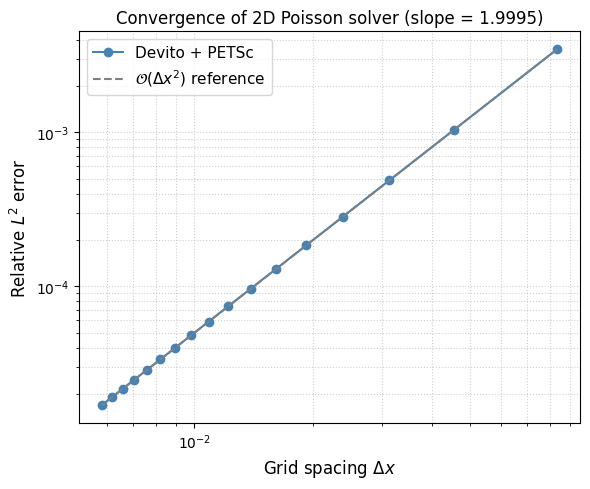

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

# Computed errors
ax.loglog(dx, errors, 'o-', color='steelblue', label='Devito + PETSc')

# Second-order reference line anchored to the first data point
ref = errors[0] * (dx / dx[0]) ** 2
ax.loglog(dx, ref, '--', color='gray', label='$\\mathcal{O}(\\Delta x^2)$ reference')

ax.set_xlabel(r'Grid spacing $\Delta x$', fontsize=12)
ax.set_ylabel(r'Relative $L^2$ error', fontsize=12)
ax.set_title(f'Convergence of 2D Poisson solver (slope = {slope:.4f})', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()